In [1]:
# execute as if in root folder for utils and filepaths
%cd ..

c:\Users\sonja\OneDrive\Uni\Semester 6\BachelorArbeit\practical-work-ai-bsc


C:\Users\sonja\AppData\Roaming\Python\Python311\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,TensorDataset
import numpy as np
import random
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import json
from torch.utils.tensorboard import SummaryWriter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, auc, precision_recall_curve , average_precision_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
import seaborn as sns

from utils import get_support_query_loaders_ep, log_results_nn_ft, NeuralNetwork, save_best_model, classification_loss, propagation_loss, getPrAucIndividualClassFinetuning

In [3]:
data = np.load('./data/data_scaled.npz')
X_finetuning = data['X_finetuning']
y_ft1 = data['y_finetuning1']
y_ft2 = data['y_finetuning2']

In [4]:
seeds = [2608, 2831, 3525, 3127, 9549, 9299, 896, 8017, 106, 7039]

In [5]:
def label_propagation(X, Y, alpha):
    """
    X: input features
    Y: one hot vector of n x c dimensions; c is num of different labels
    alpha: hyperparameter that controls how much influence neighbors get, [0,1]: 0: predict only 0s, 1: predict only 1s
    """
    device = X.device
    # affinity matrix W
    sq = torch.sum(X ** 2, dim=1, keepdim=True)  # shape: (num_samples, 1)
    distances_squared = sq + sq.t() - 2 * (X @ X.t())
    sigma2 = torch.var(distances_squared)
    W = torch.exp(-distances_squared / (2*sigma2) )
    W.fill_diagonal_(0)

    # diagonal matrix
    row_sums = torch.sum(W, dim=1)
    D12 = torch.diag(1 / torch.sqrt(row_sums))
    
    S = D12 @ W @ D12

    # F*
    I = torch.eye(X.shape[0], device=device, dtype=X.dtype)
    temp = (I - alpha * S).float()
    F_star = torch.linalg.solve(temp, Y) # solve MF = Y for F, avoid direct inverse

    # label each point x_i as y_i = argamx F*_ij
    L = torch.argmax(F_star, dim=1)

    return L


In [6]:
def prepare_labels_label_propagation(len_X_support, len_X_query, y_support, device, num_classes=2):
    y_support = y_support.clone().detach().long()
    zeros = torch.zeros((len_X_query, num_classes), dtype=torch.float, device=device)
    one_hot_y= nn.functional.one_hot(y_support, num_classes,).float().to(device)
    Y = torch.concatenate((one_hot_y, zeros))
    return Y

In [7]:
def scatterplot_propagated_labels(X, y1, y2):
    pca = PCA(n_components=2, random_state=0)
    X2 = pca.fit_transform(X)

    # Prepare subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    for ax, (y, title) in zip(axes, [(y1, 'Labels → y1'), (y2, 'Labels → y2 (None→grey)')]):
        # Find unique real classes (ignore None/nan)
        classes = [c for c in np.unique(y) if c is not None and not (isinstance(c, float) and np.isnan(c))]
        # Plot each real class with default cycle
        for cls in classes:
            mask = (y == cls)
            ax.scatter(
                X2[mask, 0], X2[mask, 1],
                label=f'Class {cls}',
                s=20, alpha=0.5, edgecolors='face'
            )
        # Plot missing (None/nan) as grey
        missing_mask = [(v is None) or (isinstance(v, float) and np.isnan(v)) for v in y]
        if any(missing_mask):
            ax.scatter(
                X2[missing_mask, 0], X2[missing_mask, 1],
                label='Missing',
                color='lightgrey',
                s=20, alpha=0.1, edgecolors='face'
            )
        ax.set_title(title, fontsize=16)
        ax.set_xlabel('PC1', fontsize=14)
        ax.set_ylabel('PC2', fontsize=14)
        ax.legend(title='Label', fontsize=12, title_fontsize=12, loc='best')
        ax.grid(True)

    plt.tight_layout()
    plt.show()

In [8]:
# task_idx = 2
# support_loader, _, support_idx, query_idx = get_support_query_loaders(X_finetuning, y_ft1, task_idx, k=1, l=30, max_pos_query=10, seed=12576, batch_size=120, num_workers=0)
# print(y_ft1[support_idx, task_idx])
# Y = prepare_labels_label_propagation(len(support_idx), len(query_idx), y_ft1[support_idx, 2])
# episode_idx = np.concatenate((support_idx, query_idx))
# propagated_labels = label_propagation(torch.tensor(X_finetuning[episode_idx], device="cuda"), torch.tensor(Y, device="cuda"), alpha=0.0000000000000001)

In [9]:
# scatterplot_propagated_labels(X_finetuning[episode_idx], propagated_labels.cpu(), y_ft1[episode_idx, task_idx])

In [10]:
def train_few_shot_model(model, X, y, task_idx, optimizer, scheduler, device, writer, run, k, l, max_pos_query, seed, alpha, alpha_ep, num_episodes=5, batch_size=120, num_workers=0):
    """
    model          : your NeuralNetwork instance
    X, y           : numpy arrays (N, D) and (N, T)
    criterion      : loss fn, e.g. BCEWithLogitsLoss()
    optimizer      : your torch optimizer
    device         : torch.device
    writer         : tensorboard writer
    run            : an identifier for the saved filename
    k, seed        : few-shot support size and RNG seed
    """
    model.to(device)
    best_score = 0.0
    file_path = f"./best_models/ft2_ep_{run}.pth"

    X = torch.from_numpy(X).float().to(device)
    y = torch.from_numpy(y).float().to(device)

    # generate support and query sets
    support_loader, query_loader, support_idx, query_idx = get_support_query_loaders_ep(X, y, alpha_ep, task_idx, k, l, max_pos_query, seed, batch_size=batch_size, num_workers=num_workers)


    for episode in range(1, num_episodes + 1):
        model.train()
        ################# TRAIN #################
        # ——— SUPPORT SET ———
        for inputs, labels in support_loader:
            # flatten if needed
            support_inputs = inputs.view(inputs.size(0), -1).to(device)
            support_labels = labels.to(device)

            optimizer.zero_grad()
            outputs_support = model(support_inputs)
            outputs_support = outputs_support.squeeze(1)

            loss_support = classification_loss(outputs_support, support_labels)

        # ——— LOSS AND UPDATE STEP ——— # 
        optimizer.zero_grad()
        loss_support.backward()
        optimizer.step()
        scheduler.step(loss_support)

    ################# EVAL #################
    # ——— QUERY SET ——— #
    model.eval()
    all_labels_val = []
    all_preds_val = []

    for inputs, labels in query_loader:
        query_inputs = inputs.to(device)
        query_labels = labels.to(device)

        outputs_query = model(query_inputs)
        outputs_query = outputs_query.squeeze(1)

        loss_query = classification_loss(outputs_query, query_labels)

        all_labels_val.append(labels.cpu().numpy())
        all_preds_val.append(torch.sigmoid(outputs_query).detach().cpu().numpy())

    y_true_final = np.concatenate(all_labels_val).astype(int)
    y_pred_final = (np.concatenate(all_preds_val) >= 0.5).astype(int)

    # ——— LABEL PROPAGATION ——— # 
    episode_idx = np.concatenate((support_idx, query_idx))
    Y = prepare_labels_label_propagation(len(support_idx), len(query_idx), y[support_idx, task_idx], device)
    propagated_labels = label_propagation(X[episode_idx], Y, alpha=alpha)
    query_logits = propagated_labels[len(support_idx):]
    loss_label_prop = propagation_loss(query_logits.float(), query_labels.float())

    # ——— EVALUATE MODEL ——— # 
    final_preds = (all_preds_val[0] + np.array(query_logits.cpu())) / 2 # final predictions are avg of model preds and label prop preds
    val_loss = classification_loss(torch.tensor(final_preds), torch.tensor(all_labels_val[0]))
    #test = [final_preds.reshape(-1)]
    val_pr_auc, val_roc_auc, val_pr_auc_per_task, val_roc_auc_per_task = getPrAucIndividualClassFinetuning(
        "Val", all_labels_val, [final_preds.reshape(-1)], writer, episode
    )


    print(
        f"=== Best Model Evaluation ===\n"
        f"Avg PR-AUC: {val_pr_auc:.4f}, Avg ROC-AUC: {val_roc_auc:.4f}"
    )

    return val_pr_auc, val_roc_auc, val_pr_auc_per_task, val_roc_auc_per_task, y_true_final, y_pred_final


In [11]:
# hyperparameters & global vars
input_size = 2248 
hidden_sizes = [120, 48, None]
output_size = 9
k = 1
batch_size = 500
dropout_rates = [0.3, 0.5] # input dropout, hidden dropout
lr = 0.2941271118953339
l = 10
max_pos_query= int(l/2)
num_episodes=11
alpha = 0.2538481528053722
alpha_ep = 0.8482506849337167
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


num_tasks = 4
num_runs  = 10

# for heatmaps
delta_arr = np.zeros((num_tasks, num_runs))
roc_arr   = np.zeros((num_tasks, num_runs))

# to hold all the raw labels / preds:
y_true_per_task = {i: [] for i in range(num_tasks)}
y_pred_per_task = {i: [] for i in range(num_tasks)}

# list to collect results avg over task
avg_results = {
        "Delta-AUC-PR": [],
        "ROC-AUC": []
    }

# list to collect results per task
all_results = {
        "Delta-AUC-PR": [],
        "ROC-AUC": []
    }  

# train and evaluate model 5 times
for task_idx in range(4):
    for run in range(10):
        # set seed
        seed_value = seeds[run]
        torch.manual_seed(seed_value)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed_value)
            torch.cuda.manual_seed_all(seed_value)
        np.random.seed(seed_value)
        random.seed(seed_value)

        # initialize
        # writer = SummaryWriter(f"manual_runs/run_36_upsampling") # tensorboard
        writer = None
        model = NeuralNetwork(input_size, hidden_sizes, output_size, dropout_rates)

        # load best model
        state_dict = torch.load("./best_models/overall_best_ep.pth", map_location=device)
        model.load_state_dict(state_dict)

        # freeze all parameters except the last layer (fc3)
        for name, param in model.named_parameters():
            if not name.startswith("fc3"):
                param.requires_grad = False

        # check if all frozen:
        for name, param in model.named_parameters():
            print(name, param.requires_grad)
            
        # replace fc3 with a new Linear that has a single output neuron
        in_features = model.fc3.in_features # keep input features as they are
        model.fc3 = nn.Linear(in_features, 1) # replace output features
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr) # filter out all parameters except last layer
        scheduler = ReduceLROnPlateau(optimizer,
                                mode='min',
                                factor=0.1,
                                patience=20,
                                min_lr=1e-6)

        # train model
        val_delta_auc_pr, val_roc_auc, val_pr_auc_per_task, val_roc_auc_per_task, y_true, y_pred = train_few_shot_model(model, X_finetuning, y_ft2, task_idx, optimizer, scheduler, device, writer, run, k, l, max_pos_query, seed_value, alpha, alpha_ep, num_episodes=num_episodes, batch_size=batch_size, num_workers=0)
        
        # collect results per run
        all_results["Delta-AUC-PR"].append(val_delta_auc_pr)
        all_results["ROC-AUC"].append(val_roc_auc) 

        delta_arr[task_idx, run] = val_delta_auc_pr
        roc_arr[task_idx,   run] = val_roc_auc

        # collect for confusion later
        y_true_per_task[task_idx].append(y_true)
        y_pred_per_task[task_idx].append(y_pred)

cuda
fc1.weight False
fc1.bias False
fc2.weight False
fc2.bias False
fc3.weight True
fc3.bias True
torch.Size([10]) torch.Size([10])
=== Best Model Evaluation ===
Avg PR-AUC: -0.0500, Avg ROC-AUC: 0.4444
fc1.weight False
fc1.bias False
fc2.weight False
fc2.bias False
fc3.weight True
fc3.bias True
torch.Size([10]) torch.Size([10])
=== Best Model Evaluation ===
Avg PR-AUC: -0.0167, Avg ROC-AUC: 0.5000
fc1.weight False
fc1.bias False
fc2.weight False
fc2.bias False
fc3.weight True
fc3.bias True
torch.Size([10]) torch.Size([10])
=== Best Model Evaluation ===
Avg PR-AUC: -0.0500, Avg ROC-AUC: 0.3889
fc1.weight False
fc1.bias False
fc2.weight False
fc2.bias False
fc3.weight True
fc3.bias True
torch.Size([10]) torch.Size([10])
=== Best Model Evaluation ===
Avg PR-AUC: -0.0375, Avg ROC-AUC: 0.2222
fc1.weight False
fc1.bias False
fc2.weight False
fc2.bias False
fc3.weight True
fc3.bias True
torch.Size([10]) torch.Size([10])
=== Best Model Evaluation ===
Avg PR-AUC: -0.0375, Avg ROC-AUC: 0.2222


In [12]:
filepath_normal = "./metrics/ep_ft2.json"
filepath_per_task = "./metrics/ep_ft2_per_task.json"
filepath_per_run = "./metrics/ep_ft2_per_run.json"
log_results_nn_ft(all_results, filepath_normal, filepath_per_run, filepath_per_task)

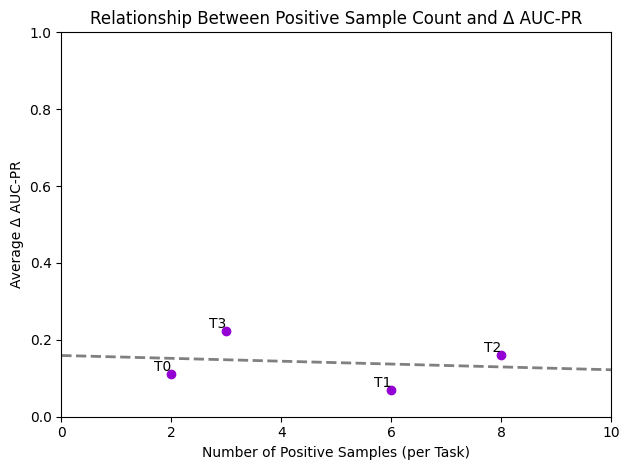

In [13]:
arr_float = y_ft2.astype(float)
pos_counts = np.nansum(arr_float == 1, axis=0)  # shape (4,)

# === 2) Compute average Δ AUC-PR per task ===
# Assuming you have collected Delta-AUC-PR into all_results as a flat list:
num_tasks = 4
num_runs  = len(all_results["Delta-AUC-PR"]) // num_tasks
delta_arr = np.array(all_results["Delta-AUC-PR"]).reshape(num_tasks, num_runs)
delta_means = delta_arr.mean(axis=1)  # shape (4,)

# === 3) Scatter plot + best-fit line ===
plt.figure()
plt.scatter(pos_counts, delta_means, color="darkviolet")
plt.xlim(0, 10)
plt.ylim(0, 1)
# best-fit line
m, b = np.polyfit(pos_counts, delta_means, 1)
x_line = np.array([0, 10])
plt.plot(x_line, m*x_line + b, color="grey", linewidth=2, linestyle='--')

for i, (x, y) in enumerate(zip(pos_counts, delta_means)):
    plt.text(x, y, f"T{i}", va='bottom', ha='right')

plt.xlabel("Number of Positive Samples (per Task)")
plt.ylabel("Average Δ AUC-PR")
plt.title("Relationship Between Positive Sample Count and Δ AUC-PR")
plt.tight_layout()
plt.show()

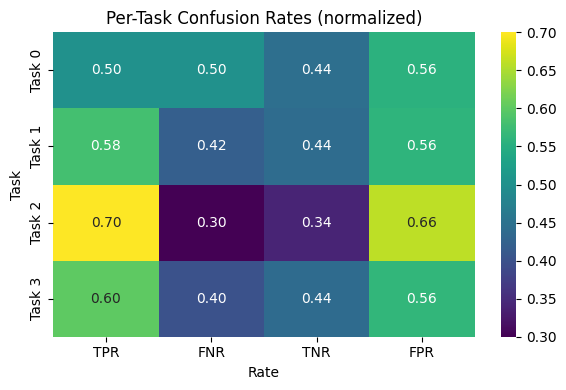

In [ ]:
counts = np.zeros((num_tasks, 4), dtype=int)
# columns = [TP, FN, TN, FP]

for i in range(num_tasks):
    # concatenate across runs
    yt = np.concatenate(y_true_per_task[i])
    yp = np.concatenate(y_pred_per_task[i])
    counts[i, 0] = np.sum((yt == 1) & (yp == 1))  # TP
    counts[i, 1] = np.sum((yt == 1) & (yp == 0))  # FN
    counts[i, 2] = np.sum((yt == 0) & (yp == 0))  # TN
    counts[i, 3] = np.sum((yt == 0) & (yp == 1))  # FP
    
num_tasks = counts.shape[0]

rates = np.zeros_like(counts, dtype=float)

for i in range(num_tasks):
    TP, FN, TN, FP = counts[i]
    pos_tot = TP + FN
    neg_tot = TN + FP

    # avoid division by zero
    if pos_tot > 0:
        rates[i, 0] = TP / pos_tot  # TPR
        rates[i, 1] = FN / pos_tot  # FNR
    if neg_tot > 0:
        rates[i, 2] = TN / neg_tot  # TNR
        rates[i, 3] = FP / neg_tot  # FPR

# now plot rates instead of raw counts
categories = ['TPR', 'FNR', 'TNR', 'FPR']
plt.figure(figsize=(6, 4))
sns.heatmap(
    rates,
    annot=True,
    fmt=".2f",
    cmap='viridis',
    xticklabels=categories,
    yticklabels=[f"Task {i}" for i in range(num_tasks)]
)
plt.title("EP-MLP Per-Task Confusion Rates (normalized)")
plt.xlabel("Rate")
plt.ylabel("Task")
plt.tight_layout()
plt.show()